# Lab 6 (ResNet18)
## Cameron Mangione

## Libraries, Data Import, Data Preprocessing

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots
from sklearn.linear_model import \
     (LinearRegression,
      LogisticRegression,
      Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import \
     (train_test_split,
      GridSearchCV)
from sklearn.metrics import confusion_matrix

In [2]:
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset, DataLoader #Data Loader for loading CIFAR10 data to ResNet50
from torchmetrics import (MeanAbsoluteError,
                          R2Score)
from torchinfo import summary
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import Trainer
from pytorch_lightning import seed_everything
seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)
from torchvision.datasets import MNIST, CIFAR10
from torchvision.models import (resnet50,
                                ResNet50_Weights,resnet18,
                                ResNet18_Weights)
from torchvision.transforms import (Resize,
                                    Normalize,
                                    CenterCrop,
                                    ToTensor, Compose) #Compose added here for function needed for CIFAR10
from tqdm import tqdm
import time

Seed set to 0


Source for Compose method: https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.Compose.html

We first start defining a few functions:
1. Our general 'transform' function that
   - Resizes our image to 224 by 224 for ResNet50
   - A tensor method to convert our training data to tensors since we are dealing with CIFAR10 data
   - And then a normalize function that standardizes the images.
2. Our number of workers utilizing iour ISLP.torch rec_num_workers

In [3]:
transform = Compose([Resize((224,224), antialias=True),ToTensor(),Normalize([0.485,0.456,0.406],
                      [0.229,0.224,0.225])])

We then import our CIFAR10 dataset with our transform function on our training and test data.

In [4]:
(cifar_train, 
 cifar_test) = [CIFAR10(root="data",
                         train=train,
                         download=True,transform=transform)
             for train in [True, False]]

Source for DataLoader function: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

From here, we can utilize a DataLoader from torch.utils.data to create the objects that we need to run our models.

We use a batch size of 30 here to make our model easier to run since we do not have a gpu accessible at this point and it makes running our dataset easier since we have 50k training data points and 10k testing data points.

The shuffle changes the data at each epoch so we don't overtest or overtrain our data.

In [5]:
train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True) #Load training data
test_loader = DataLoader(cifar_test, batch_size=64, shuffle=False) #Load test data

We then set up our ResNet50 model with default weights applied, which is equivalent to pretraining our model in this case. 

In [7]:
print(f'Train Loader Length: {len(train_loader)}')

Train Loader Length: 782


In [8]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
resnet_model2 = resnet18(weights=ResNet18_Weights.DEFAULT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model = resnet_model.to(device)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model = resnet_model2.to(device2)

In [9]:
for p in resnet_model2.parameters():
    p.requires_grad = False

In [10]:
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)
resnet_model2.fc = nn.Linear(resnet_model2.fc.in_features, 10)

The .eval() method lets us look at the breakdown of our ResNet 50 structure and also helps us see the breakdown of the bottlenecks. 

The input layer is where we use our CIFAR10 data is the initial step, adn then this data is applied across each of this model's layers.

We set up our linear resnet model here for training with our 10 classes from CIFAR10, our optimizer RMSprop method with a learning rate of 0.001, and then a cross-entropy loss function to calculate our training and test loss.

We also set up our CSVLogger at this stage for our training results as well.

In [11]:
resnet_optimizer = RMSprop(resnet_model.parameters(), lr=0.001)
resnet_loss = nn.CrossEntropyLoss()
resnet_optimizer2 = RMSprop(resnet_model2.parameters(), lr=0.001)
resnet_loss2 = nn.CrossEntropyLoss()

In [12]:
resnet_logger = CSVLogger("logs", name="resnet50")

## Implementation

We start with a final test to show that our training loader varaible is working before getting into our full test

In [13]:
for batch_idx, (inputs, labels) in enumerate(train_loader):
    if batch_idx >= 5:
        break
    print(f'Batch {batch_idx+1}: {inputs.size()}, {labels.size()}')

Batch 1: torch.Size([64, 3, 224, 224]), torch.Size([64])
Batch 2: torch.Size([64, 3, 224, 224]), torch.Size([64])
Batch 3: torch.Size([64, 3, 224, 224]), torch.Size([64])
Batch 4: torch.Size([64, 3, 224, 224]), torch.Size([64])
Batch 5: torch.Size([64, 3, 224, 224]), torch.Size([64])


Since we are using ResNet 50, our code takes around ~3 hours to run, so I went ahead and stored the results in raw cells for reference.

We record both loss and accuracy in our loop here and also utilize our tqdm function to track our progress along the way.

In [22]:
train_losses = []
train_accuracies = []
test_accuracies = []
test_losses = []
epochs = 10

for epoch in range(epochs):
    start_time = time.time()
    resnet_model2.train()
    running_loss = 0.0
    total = 0
    correct = 0
    for batch_idx, (inputs, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False)):
        resnet_optimizer2.zero_grad()   
        outputs = resnet_model2(inputs)  
        loss = resnet_loss2(outputs, labels)
        loss.backward()          
        resnet_optimizer2.step()         
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    avg_loss = running_loss / len(train_loader)
    accuracy = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    resnet_model2.eval()
    test_correct = 0
    test_total = 0
    test_loss = 0
    batches = 0
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating', leave=False):
            outputs = resnet_model2(inputs)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            loss = resnet_loss2(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            batches += 1
    
    test_accuracy = test_correct / test_total
    test_average_loss = test_loss / test_total

    test_accuracies.append(test_accuracy)
    test_losses.append(test_average_loss)
    
    end_time = time.time()
    epoch_duration = end_time - start_time
    minutes, seconds = divmod(epoch_duration, 60)
    print(f'Duration: {int(minutes)}m {seconds:.2f}s')
    resnet_logger.log_metrics({"train_loss": avg_loss, "train_accuracy": accuracy}, step=epoch)
    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')
    print(f'Test_Loss: {test_average_loss:.4f}')
    print(f'Test_Accuracy: {test_accuracy:.4f}')

Duration: 6m 57.09s
Epoch [1/10], Loss: 0.5482, Accuracy: 0.8099
Test_Loss: 0.5875
Test_Accuracy: 0.8018


Duration: 7m 12.27s
Epoch [2/10], Loss: 0.5482, Accuracy: 0.8088
Test_Loss: 0.6151
Test_Accuracy: 0.7929


Duration: 6m 53.46s
Epoch [3/10], Loss: 0.5418, Accuracy: 0.8112
Test_Loss: 0.5787
Test_Accuracy: 0.8046


Duration: 7m 21.73s
Epoch [4/10], Loss: 0.5443, Accuracy: 0.8110
Test_Loss: 0.6088
Test_Accuracy: 0.7933


Duration: 7m 20.18s
Epoch [5/10], Loss: 0.5438, Accuracy: 0.8113
Test_Loss: 0.6395
Test_Accuracy: 0.7839


Duration: 6m 54.69s
Epoch [6/10], Loss: 0.5381, Accuracy: 0.8145
Test_Loss: 0.5928
Test_Accuracy: 0.7959


Duration: 7m 13.44s
Epoch [7/10], Loss: 0.5405, Accuracy: 0.8115
Test_Loss: 0.6416
Test_Accuracy: 0.7801


Duration: 7m 11.53s
Epoch [8/10], Loss: 0.5380, Accuracy: 0.8130
Test_Loss: 0.6128
Test_Accuracy: 0.7898


Duration: 6m 41.32s
Epoch [9/10], Loss: 0.5398, Accuracy: 0.8118
Test_Loss: 0.6140
Test_Accuracy: 0.7923


Duration: 6m 57.78s
Epoch [10/10], Loss: 0.5403, Accuracy: 0.8114
Test_Loss: 0.6838
Test_Accuracy: 0.7701


We store our training data in a dataframe for creating our plotsand set the index as epochs as well. Once this is complete, we test our data after training it.

In [27]:
d2 = {"epoch": [1,2,3,4,5,6,7,8,9,10], "train_loss": train_losses, "train_accuracy": train_accuracies,  "test_loss": test_losses, "test_accuracy": test_accuracies}
rn18_data = pd.DataFrame(data=d2)
rn18_data.set_index('epoch', drop=True)

,train_loss,train_accuracy,test_loss,test_accuracy
epoch,,,,
1,0.548157,0.80988,0.587505,0.8018
2,0.548231,0.80876,0.615107,0.7929
3,0.541835,0.81116,0.578709,0.8046
4,0.544309,0.81102,0.608837,0.7933
5,0.543781,0.81130,0.639455,0.7839
6,0.538124,0.81446,0.592828,0.7959
7,0.540524,0.81148,0.641569,0.7801
8,0.537951,0.81300,0.612791,0.7898
9,0.539829,0.81184,0.614039,0.7923


With our model trained, we now can proceed with testing to collect our testing results.

We now create our plot to show where our test data compares after training our full model.

10 epochs turned out to be a good estimation for finding where our model performance starts to even out.

Our test results around 82% is lower than our training but not by too much and is still a great result overall.

Cross validation can be explored here since there was some slight variance away from the training model.

## Plot Results

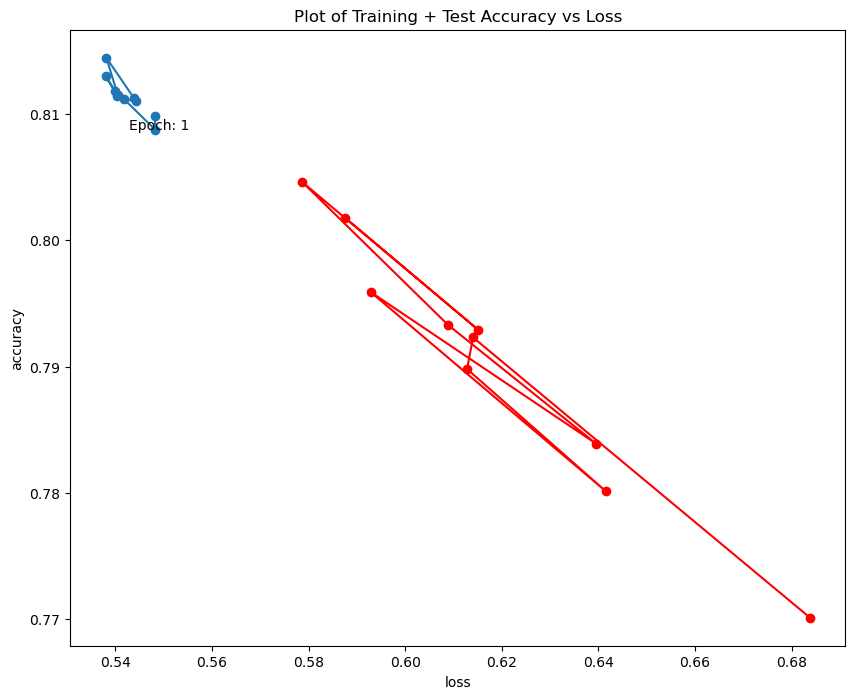

In [28]:
plt.figure(figsize=(10, 8))
plt.plot(rn18_data['train_loss'],rn18_data['train_accuracy'], label="Line", marker="o")

for i in range(1):
    offset = (10 * (i % 2) - 10)
    plt.annotate(f'Epoch: {i+1}',
                 (train_data['loss'][i], train_data['accuracy'][i]),
                 textcoords="offset points",
                 xytext=(3, offset),
                 ha='center')


plt.plot(rn18_data['test_loss'],rn18_data['test_accuracy'], label='Test Results', marker='o', color='red')


plt.annotate('Test Results',
             (test_loss, test_accuracy),
             textcoords="offset points",
             xytext=(3, 10),
             ha='center', color='red')

plt.xlabel('loss')
plt.ylabel('accuracy')
plt.title('Plot of Training + Test Accuracy vs Loss')
plt.show()

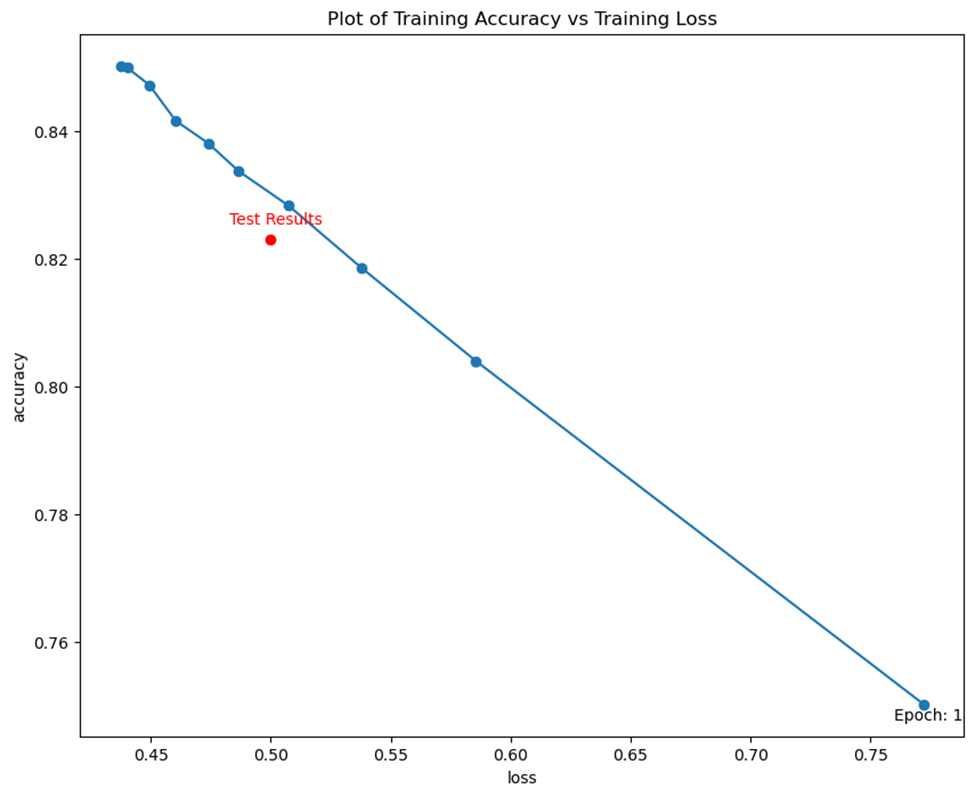

## Written Description

Source utilized in describing for model description: https://medium.com/@deepvisionkararhaider/resnet-50-explained-step-by-step-the-easiest-guide-to-deep-residual-networks-7616f4f45046

Written description on the following:
- Description on the pretrained model used:
    - Our model that we used here ResNet50, which stands for residual networks. Most deep netural networks can face an issue of adding more layers making their networks run worse. ResNetsolves this issue by examing the residual between outputs and input data and then adds that residual back into the overall model. ResNet50 can examine images of the size 224x224x3(for rgb) that starts with a 7x7 convolution with 64 filters for a 112x112x64 output. It then has four convolution layers with 3, 4, 6, and 3 bottlenecks respectively. These bottlenecks are equivalent to building that were used in building our initial CNNs. The first non-initial stage has 256 channels and a spatial size of 56x56, and decreases incrementally at each stage by dividing by two for the spatial size and multiplying by two for the outputs with the final stage having an output of 2048 channels and a spatial size of 7x7. The final layer pools the spatial sizes and the outpues, along with a fully connected layer for the full model. In total, this model has 50 layers, which is why it is called ResNet50.
    - ResNEt18 is similar but iwth 18 layers instead of 50.
- Batch size, epoch, hyperparameter choice
    - Most of our decisions here were based on performance balanced with runtime and computation limitations. With this in mind, we chose a batch size of 64 for both training and testing, 10 epochs as this balanced computation time while still indicating where our model started to show less improvement (perfroamcne plateau) in training accuracy and loss, and we measured CrossEntropy Loss as our loss, a learning rate of 0.01 RMSprop (Root Mean Square) for our optimizer, and mean accuracy score for our metrics and hyperparameter choices.
- Analysis on the plot
    - We see from our plot that there was a significant increase from our first epoch to our second epoch (approximately +5% in accuracy, and around an 18-19% drop in loss). Our epcohs after this point showed reasonably improved perforamcne at each step, but started to flatten out by the 10th epoch around 86%. Our test data as a result consistently performed around 82-82.5%, which was not far off from our training results overall, but we did see a bit of a dip in perforamnce compared to training. Our test results could have likely been improveed by some corss-validation, which is someothing we will look into as a group for our presentation next week.
    - Our ResNet18 plot did not show a point of convergence and also showed more test variability compared to the training results. Like in the ResNet50 description, cross-validation may need to be further explored here as well.
- What you find interesting or different compared to CNN on CIFAR10 from last week
    - I think the utilization of residuals in ResNet50 and the adaptability of the model at each stage is a great way to improve on the CNN models that we worked on last week. Adding in considerations for residuals into these models I think improves this kind of analysis overall and makes for a more complex model that can add layers more consistently without sacrificing performance as described as an initial tradeoff in this model.